# PyTorch 训练流程实验课 — 从零训练一个分类器

## 这一课把前面所有知识串起来

到第 5 课为止，你已经学会了所有零件：

| 零件 | 课 | 作用 |
|------|----|------|
| **Tensor** | 01 | 数据载体 |
| **Autograd** | 02 | 自动算梯度 |
| **nn.Module** | 03 | 定义模型 |
| **Loss + Optimizer** | 04 | 衡量差距 + 调参数 |
| **Dataset + DataLoader** | 05 | 喂数据 |

第 6 课做一件事：**把它们组装成一台完整的「训练机器」**，让你亲眼看到「模型从瞎猜到学会」。

```
数据 ──→ DataLoader ──┐
                      ├──→ [训练循环] ──→ 学好的模型
模型 + Loss + Optim ──┘
              ↑
        每个 epoch: 训练一遍 + 验证一遍
```

配合 `tutorial/06_training_loop.py` 学习。练习在 `practice/06_training.py`。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

print(f"PyTorch version: {torch.__version__}")
print("用到的模块: torch, torch.nn, torch.optim, torch.utils.data, matplotlib")

PyTorch version: 2.12.1
用到的模块: torch, torch.nn, torch.optim, torch.utils.data, matplotlib


## 1. 准备数据 — 合成一个三分类数据集

为了让训练过程清晰可见，我们用**二维**合成数据（只有 2 个特征，方便画图）。3 个类各自围绕一个中心点，加上高斯噪声。

```
        类2 (center 0,8)
              ●●●
              
                      
        类0        类1
      ●●●        ●●●
    (0,0)       (5,5)
```

这是教学最常用的数据——**人眼一眼就能看出答案**，所以模型学得好不好，你直接看图就知道。

准备数据 — 合成三分类
数据集: X.shape=(600, 2), y.shape=(600,)
类别分布: [200, 200, 200]  (每类 200)

训练集: 480 样本, 验证集: 120 样本


/Users/oujunyi/code/learn/torch/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/oujunyi/code/learn/torch/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/oujunyi/code/learn/torch/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/oujunyi/code/learn/torch/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/oujunyi/code/learn/torch/.venv/lib/python3.12/site-packages/I

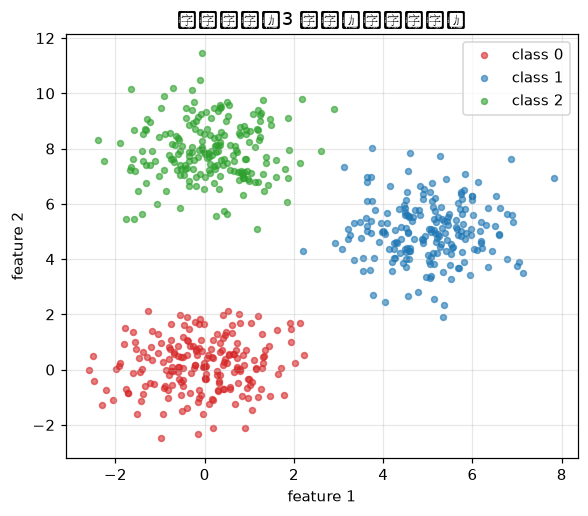

In [2]:
# --- 合成三分类数据 ---
print("=" * 60)
print("准备数据 — 合成三分类")
print("=" * 60)

torch.manual_seed(42)

def make_data(n_per_class=200, n_features=2):
    X_list, y_list = [], []
    centers = [(0, 0), (5, 5), (0, 8)]   # 3 个类的中心
    for i, (cx, cy) in enumerate(centers):
        X = torch.randn(n_per_class, n_features)
        X[:, 0] += cx
        X[:, 1] += cy
        X_list.append(X)
        y_list.append(torch.full((n_per_class,), i))
    return torch.cat(X_list, dim=0), torch.cat(y_list, dim=0)

X, y = make_data()
print(f"数据集: X.shape={tuple(X.shape)}, y.shape={tuple(y.shape)}")
print(f"类别分布: {torch.bincount(y).tolist()}  (每类 200)")
print()

# 划分训练 / 验证 (80% / 20%)
perm = torch.randperm(len(X))
n_train = int(0.8 * len(X))
train_idx, val_idx = perm[:n_train], perm[n_train:]

train_ds = TensorDataset(X[train_idx], y[train_idx])
val_ds   = TensorDataset(X[val_idx],   y[val_idx])
print(f"训练集: {len(train_ds)} 样本, 验证集: {len(val_ds)} 样本")

# 看一眼数据长啥样
fig, ax = plt.subplots(figsize=(6, 5))
for cls, color in zip([0, 1, 2], ['tab:red', 'tab:blue', 'tab:green']):
    mask = y == cls
    ax.scatter(X[mask, 0], X[mask, 1], c=color, s=15, alpha=0.6, label=f'class {cls}')
ax.set_title('合成数据：3 个类（人眼可分）')
ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 2. DataLoader — 把数据切成 batch

复习第 5 课的内容。注意一个**重要约定**：

- 训练集 `shuffle=True`：每个 epoch 打乱，避免模型记住顺序
- 验证集 `shuffle=False`：顺序无所谓，关掉保证可复现

In [3]:
# --- 训练 / 验证 DataLoader ---
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

print(f"train_loader: {len(train_loader)} 个 batch  ({len(train_ds)}/32)")
print(f"val_loader:   {len(val_loader)} 个 batch  ({len(val_ds)}/64)")
print()

# 看一个 batch
x0, y0 = next(iter(train_loader))
print(f"一个 batch: x.shape={tuple(x0.shape)}, y.shape={tuple(y0.shape)}")
print(f"  这个 batch 的标签: {y0.tolist()}")

train_loader: 15 个 batch  (480/32)
val_loader:   2 个 batch  (120/64)

一个 batch: x.shape=(32, 2), y.shape=(32,)
  这个 batch 的标签: [1, 1, 2, 1, 1, 2, 0, 0, 0, 2, 0, 2, 2, 0, 2, 1, 2, 2, 1, 2, 0, 0, 2, 0, 2, 1, 2, 0, 1, 1, 1, 2]


## 3. 定义模型 — 一个小 MLP

这是个 3 分类问题，输入 2 维，所以网络是：

```
input (2维)
  ↓ Linear(2 → 16) + ReLU
  ↓ Linear(16 → 16) + ReLU
  ↓ Linear(16 → 3)          ← 输出 3 个 logits（不要 Softmax！）
```

最后一层输出 **3 个 raw logits**，交给 `CrossEntropyLoss`（它内部会做 Softmax，第 4 课讲过）。

| 组件 | 大小 | 说明 |
|------|------|------|
| 输入 | 2 | 2 个特征 |
| 隐藏层 1 | 16 | ReLU 激活 |
| 隐藏层 2 | 16 | ReLU 激活 |
| 输出 | 3 | 3 个类的 logits |

In [4]:
# --- 定义模型 ---
print("=" * 60)
print("定义模型 — MLP")
print("=" * 60)

class Classifier(nn.Module):
    def __init__(self, input_dim=2, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes),   # 输出 logits，不加 Softmax
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier().to(device)
print(f"设备: {device}")
print(f"模型结构:\n{model}")
print(f"参数量: {sum(p.numel() for p in model.parameters())}")

定义模型 — MLP
设备: cpu
模型结构:
Classifier(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)
参数量: 371


## 4. 配置 Loss + Optimizer

- **Loss**: `nn.CrossEntropyLoss()` — 多分类标准选择，输入 raw logits
- **Optimizer**: `optim.Adam(lr=0.01)` — 自适应学习率，比 SGD 更省心（第 4 课讲过为什么）

```python
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
```

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(f"Loss:      CrossEntropyLoss  (输入 raw logits)")
print(f"Optimizer: Adam(lr=0.01)")

Loss:      CrossEntropyLoss  (输入 raw logits)
Optimizer: Adam(lr=0.01)


## 5. 训练 vs 验证 — 两个核心函数

这是整个训练流程的**心脏**。注意训练和验证的关键区别：

| | 训练 (`train_one_epoch`) | 验证 (`evaluate`) |
|---|---|---|
| 模式 | `model.train()` | `model.eval()` |
| 梯度 | 算 + 反传 + 更新 | `@torch.no_grad()` 完全不算 |
| 目的 | 学参数 | 只看效果 |

**为什么 `model.train()` / `model.eval()` 重要？** 因为 `Dropout` 和 `BatchNorm` 在两种模式下行为不同：
- 训练时 Dropout 随机丢神经元；评估时关掉（用全部神经元）
- 训练时 BatchNorm 用当前 batch 的统计；评估时用累积的全局统计

In [6]:
# --- 训练一个 epoch ---
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                          # ← 训练模式（Dropout/BN 行为）
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()              # ① 清梯度
        pred = model(x)                    # ② 前向
        loss = criterion(pred, y)          # ③ 算损失
        loss.backward()                    # ④ 反传
        optimizer.step()                   # ⑤ 更新参数

        total_loss += loss.item() * x.size(0)
        correct += (pred.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

# --- 验证（不算梯度，不更新参数）---
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()                           # ← 评估模式
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = criterion(pred, y)
        total_loss += loss.item() * x.size(0)
        correct += (pred.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

print("✅ 定义好了 train_one_epoch() 和 evaluate()")

✅ 定义好了 train_one_epoch() 和 evaluate()


## 6. 训练循环 — 见证「模型从瞎猜到学会」

现在把所有东西串起来。每个 epoch：
1. 用 `train_one_epoch` 在训练集上学一遍
2. 用 `evaluate` 在验证集上看效果（不学习，只评估）
3. 记录 loss 和准确率，画曲线

> 💡 **随机猜三分类的准确率是 1/3 ≈ 0.33**。如果训练后 val_acc 远高于 0.33，说明模型真学到了东西。

In [7]:
# --- 开始训练！ ---
print("=" * 60)
print("训练循环 — 每个 epoch 训练 + 验证")
print("=" * 60)
print("(随机猜的准确率基线 = 1/3 ≈ 0.333)\n")

num_epochs = 30
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(num_epochs):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.3f} | "
              f"Val Loss {va_loss:.4f} Acc {va_acc:.3f}")

print(f"\n🎉 训练完成！最终验证准确率: {val_accs[-1]:.3f}  (基线 0.333)")

训练循环 — 每个 epoch 训练 + 验证
(随机猜的准确率基线 = 1/3 ≈ 0.333)

Epoch   1/30 | Train Loss 0.5252 Acc 0.831 | Val Loss 0.1969 Acc 0.958
Epoch   5/30 | Train Loss 0.0044 Acc 1.000 | Val Loss 0.0032 Acc 1.000
Epoch  10/30 | Train Loss 0.0034 Acc 1.000 | Val Loss 0.0013 Acc 1.000
Epoch  15/30 | Train Loss 0.0019 Acc 1.000 | Val Loss 0.0010 Acc 1.000
Epoch  20/30 | Train Loss 0.0058 Acc 0.998 | Val Loss 0.0164 Acc 0.992
Epoch  25/30 | Train Loss 0.0135 Acc 0.996 | Val Loss 0.0006 Acc 1.000
Epoch  30/30 | Train Loss 0.0006 Acc 1.000 | Val Loss 0.0004 Acc 1.000

🎉 训练完成！最终验证准确率: 1.000  (基线 0.333)


## 7. 训练曲线 — 诊断模型健康度

画两条曲线是**训练调试的第一工具**。读图方法：

| 曲线形状 | 含义 |
|----------|------|
| 训练 ↓ 验证 ↓，两者接近 | ✅ 健康，正常收敛 |
| 训练 ↓ 验证 ↗ 后又 ↑ | ❌ **过拟合**：模型在背训练集，泛化变差 |
| 训练一直 ↗ 不下降 | ❌ **欠拟合**：lr 太大 / 模型太小 / 没学到 |
| 训练验证都不动 | ❌ 没在学（梯度消失 / 死神经元）|

/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/984485430.py:16: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/984485430.py:16: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/984485430.py:16: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/984485430.py:16: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/oujunyi/code/learn/torch/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from fo

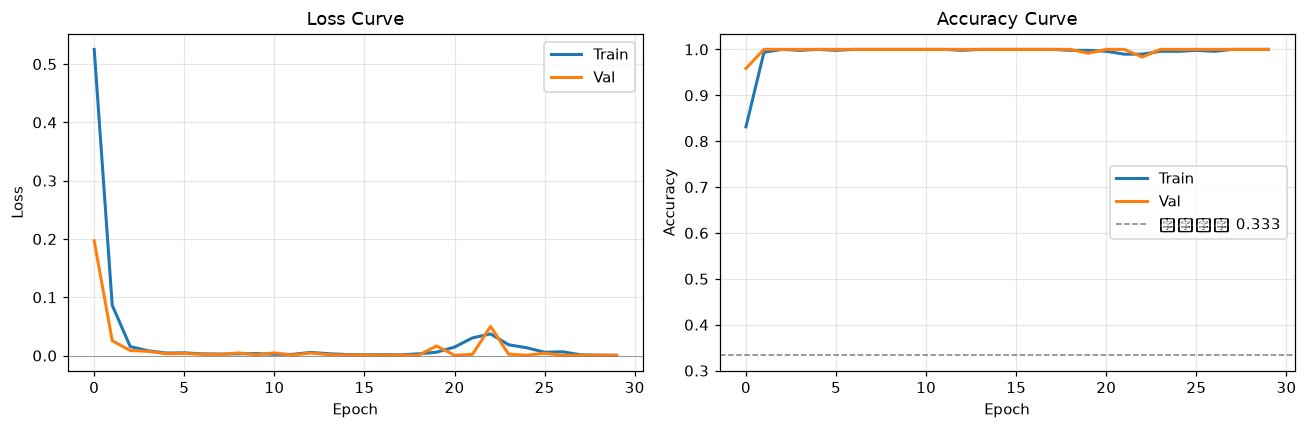

最终: Train Acc 1.000, Val Acc 1.000
Gap (Train - Val): +0.000  → 接近 0 = 没有过拟合


In [8]:
# --- Loss & 准确率曲线 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train', linewidth=2)
ax1.plot(val_losses, label='Val', linewidth=2)
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train', linewidth=2)
ax2.plot(val_accs, label='Val', linewidth=2)
ax2.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='随机基线 0.333')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"最终: Train Acc {train_accs[-1]:.3f}, Val Acc {val_accs[-1]:.3f}")
print(f"Gap (Train - Val): {train_accs[-1] - val_accs[-1]:+.3f}  → 接近 0 = 没有过拟合")

## 8. 决策边界 — 看模型到底学到了什么

把整个二维平面喂给模型，看它在每个点预测哪个类。背景颜色 = 模型的预测，散点 = 真实数据。**背景颜色区域和散点颜色对得越齐，模型学得越好**。

```
   ┌─────────────────────┐
   │  把每个网格点喂模型   │
   │  grid (200×200)     │
   │       ↓             │
   │  model(grid)        │
   │       ↓             │
   │  argmax → 预测类别   │
   │       ↓             │
   │  contourf 上色      │
   └─────────────────────┘
```

/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/21323549.py:24: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/21323549.py:24: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/21323549.py:24: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/21323549.py:24: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/21323549.py:24: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  p

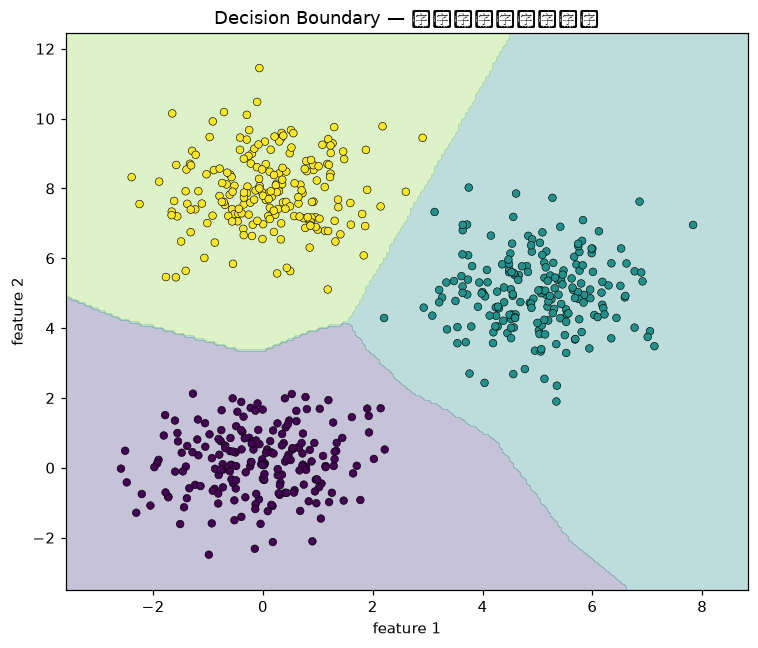

✅ 模型把二维空间切成了 3 块，几乎完美对应 3 个真实类别


In [9]:
# --- 决策边界 ---
@torch.no_grad()
def plot_decision_boundary(model, X, y, device, ax=None):
    model.eval()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200),
        torch.linspace(y_min, y_max, 200),
        indexing='ij',
    )
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1).to(device)
    pred = model(grid).argmax(dim=1).cpu().reshape(xx.shape)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    ax.contourf(xx, yy, pred, alpha=0.3, cmap='viridis', levels=[-0.5, 0.5, 1.5, 2.5])
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=25, linewidth=0.4)
    ax.set_title('Decision Boundary — 模型学到的分类区域')
    ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2')
    return ax

plot_decision_boundary(model, X, y, device)
plt.tight_layout(); plt.show()
print("✅ 模型把二维空间切成了 3 块，几乎完美对应 3 个真实类别")

## 9. 推理 — 用训好的模型预测新样本

训练完的模型怎么用？三步：
1. `model.eval()` — 切评估模式（关 Dropout/固定 BN）
2. `with torch.no_grad():` — 不算梯度（省内存、省时间）
3. `pred = model(x)` → `pred.argmax(dim=1)` 取最大 logit 的类

`argmax(dim=1)` 的意思：对每个样本（dim=1 是类别维），返回分数最高的那个类的**索引**。

In [10]:
# --- 推理 ---
print("=" * 60)
print("推理 — 预测新样本")
print("=" * 60)

# 造几个新点（模型从没见过）
new_points = torch.tensor([
    [0.0, 0.0],   # 应该是类 0（中心附近）
    [5.0, 5.0],   # 应该是类 1
    [0.0, 8.0],   # 应该是类 2
    [2.5, 4.0],   # 边界附近，不确定
]).to(device)

model.eval()
with torch.no_grad():
    logits = model(new_points)
    probs = torch.softmax(logits, dim=1)         # 这次手动 Softmax 看置信度
    preds = logits.argmax(dim=1)

print(f"{'点':<12} {'预测类':<8} {'置信度':<20}")
print("-" * 42)
for pt, p, prob in zip(new_points.tolist(), preds.tolist(), probs.tolist()):
    print(f"{str(pt):<12} {p:<8} {[f'{x:.2f}' for x in prob]}")

print("\n💡 推理三件套: model.eval() + torch.no_grad() + argmax(dim=1)")

推理 — 预测新样本
点            预测类      置信度                 
------------------------------------------
[0.0, 0.0]   0        ['1.00', '0.00', '0.00']
[5.0, 5.0]   1        ['0.00', '1.00', '0.00']
[0.0, 8.0]   2        ['0.00', '0.00', '1.00']
[2.5, 4.0]   1        ['0.02', '0.98', '0.00']

💡 推理三件套: model.eval() + torch.no_grad() + argmax(dim=1)


## 10. 故意制造过拟合 — 看曲线怎么变

把训练集**缩到极小**（比如 12 个样本），模型参数（129 个）远多于数据，模型会开始**背**训练集——训练准确率冲到 100%，但验证准确率反而下降。这就是**过拟合**。

**正则化手段**（本课不展开，但要知道有这些武器）：
- 加更多数据
- `Dropout` — 随机丢神经元
- Weight decay（L2 正则）— `optim.Adam(..., weight_decay=1e-4)`
- 早停（Early stopping）— 验证 loss 不降了就停

过拟合演示 — 训练集缩到 12 个样本
训练集（12 样本）准确率: 0.833  ← 接近 100% = 在背答案
验证集（120 样本）准确率: 0.525  ← 明显更低 = 泛化差


/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/394378045.py:30: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/394378045.py:30: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/394378045.py:30: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/394378045.py:30: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3t/v4xdvt852f99mjlvlg9c2l380000gn/T/ipykernel_24954/394378045.py:30: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tig

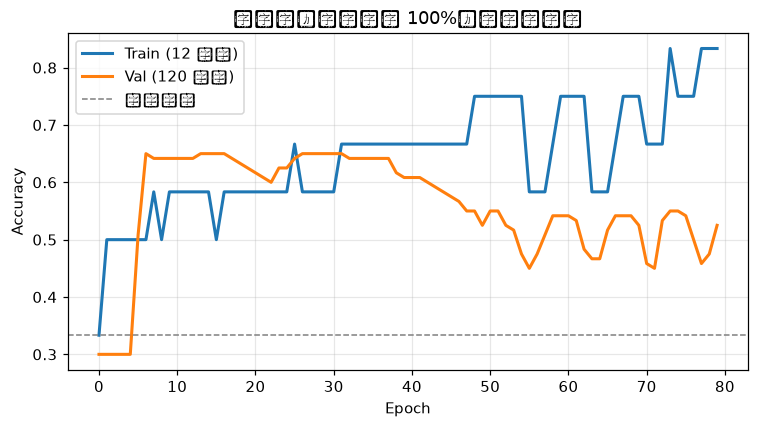


→ 训练和验证的 gap 越大，过拟合越严重


In [11]:
# --- 过拟合演示 ---
print("=" * 60)
print("过拟合演示 — 训练集缩到 12 个样本")
print("=" * 60)

torch.manual_seed(0)
tiny_X = X[torch.randperm(len(X))[:12]]
tiny_y = y[torch.randperm(len(y))[:12]]
tiny_train = TensorDataset(tiny_X, tiny_y)
tiny_loader = DataLoader(tiny_train, batch_size=12, shuffle=True)

overfit_model = Classifier().to(device)
opt_of = optim.Adam(overfit_model.parameters(), lr=0.01)

of_tr, of_va = [], []
for epoch in range(80):
    tr_loss, tr_acc = train_one_epoch(overfit_model, tiny_loader, criterion, opt_of, device)
    va_loss, va_acc = evaluate(overfit_model, val_loader, criterion, overfit_model.net[0].weight.device)
    of_tr.append(tr_acc); of_va.append(va_acc)

print(f"训练集（12 样本）准确率: {of_tr[-1]:.3f}  ← 接近 100% = 在背答案")
print(f"验证集（120 样本）准确率: {of_va[-1]:.3f}  ← 明显更低 = 泛化差")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(of_tr, label='Train (12 样本)', linewidth=2)
ax.plot(of_va, label='Val (120 样本)', linewidth=2)
ax.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='随机基线')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('过拟合：训练冲到 100%，验证跟不上'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("\n→ 训练和验证的 gap 越大，过拟合越严重")

## 📝 核心速查

### 完整训练流程 = 以下步骤的循环

```
① 准备数据
    Dataset + DataLoader(batch_size, shuffle)
    train_loader: shuffle=True, val_loader: shuffle=False

② 定义模型
    class MyModel(nn.Module):
        def forward(self, x): return self.net(x)
    model = MyModel().to(device)

③ 选 Loss + Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

④ 训练循环
    for epoch in range(num_epochs):
        # —— 训练 ——
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
        # —— 验证 ——
        model.eval()
        with torch.no_grad():
            for x, y in val_loader: ...
```

### 训练 vs 验证（最关键的区别）

| | 训练 | 验证 |
|---|---|---|
| 模式 | `model.train()` | `model.eval()` |
| 梯度 | `loss.backward()` + `optimizer.step()` | `with torch.no_grad():` |
| 目的 | 学参数 | 只评估 |

### 训练曲线怎么读

| 现象 | 诊断 | 解药 |
|------|------|------|
| 训练验证都下降 | ✅ 健康 | 继续 |
| 训练↓ 验证↑ | 过拟合 | 加数据 / Dropout / weight_decay / 早停 |
| 都不下降 | 欠拟合 | 大模型 / 大 lr / 更多 epoch |
| Loss = NaN | lr 太大 / 数值爆炸 | 降 lr，检查输入 |

### 常见误区

| ❌ 错误 | ✅ 正确 |
|---------|---------|
| 验证时忘了 `model.eval()` | eval 关 Dropout/固定 BN |
| 验证时算梯度 | `with torch.no_grad():` 省内存 |
| CrossEntropyLoss 后自己 argmax 再算 loss | 直接喂 raw logits |
| 只看训练 loss | **必须**同时看验证 loss |
| 训练验证不分（同一份数据） | 严格分开，验证集不能参与训练 |

### 推理三件套

```python
model.eval()
with torch.no_grad():
    pred = model(x).argmax(dim=1)
```

👉 下一步：去 `practice/06_training.py` 刷题！